supervised learning

regression(linear, polynomial)

In [1]:
from sklearn.datasets import load_wine
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import pandas as pd


In [ ]:
wine = load_wine()
x = pd.DataFrame(wine.data, columns=wine.feature_names)
y  = x['alcohol']      # target: alcohol content
X = x.drop(columns=['alcohol'])

In [ ]:
x

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
y

,alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


In [ ]:
linear = linear_model.LinearRegression()

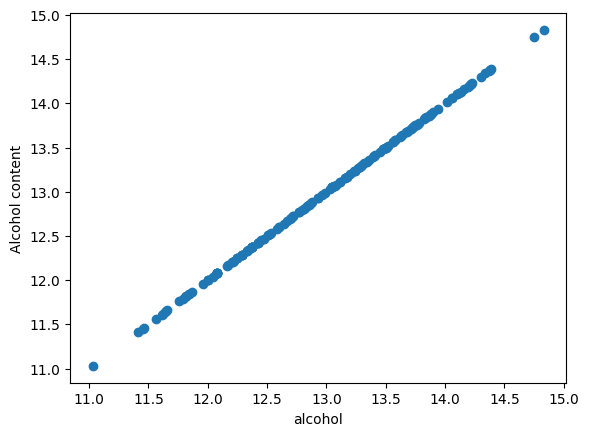

In [ ]:
plt.scatter(x.iloc[:,0], y)
plt.xlabel(x.columns[0])
plt.ylabel('Alcohol content')
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
m = linear.fit(x_train, y_train)

In [ ]:
m.predict(x_test)

array([13.64, 14.21, 12.93, 13.73, 12.37, 14.3 , 12.  , 13.4 , 11.61,
       13.36, 13.5 , 13.5 , 13.41, 12.77, 13.63, 12.52, 11.41, 12.08,
       13.86, 12.08, 14.19, 13.11, 12.33, 13.4 , 12.77, 13.78, 12.42,
       12.37, 12.08, 13.56, 14.02, 12.37, 13.16, 13.58, 13.75, 13.88])

In [ ]:
x1, x2, y1, y2 = train_test_split(x, y, test_size=0.2, random_state=42)
m = linear.fit(x1, y1)

In [ ]:
m.predict(x2)

array([13.64, 14.21, 12.93, 13.73, 12.37, 14.3 , 12.  , 13.4 , 11.61,
       13.36, 13.5 , 13.5 , 13.41, 12.77, 13.63, 12.52, 11.41, 12.08,
       13.86, 12.08, 14.19, 13.11, 12.33, 13.4 , 12.77, 13.78, 12.42,
       12.37, 12.08, 13.56, 14.02, 12.37, 13.16, 13.58, 13.75, 13.88])

/tmp/ipython-input-4157892922.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


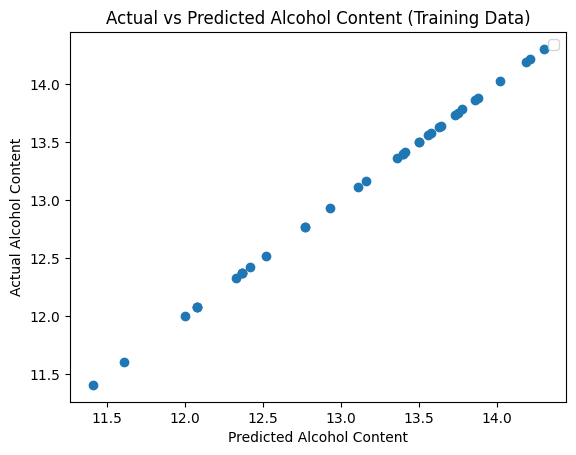

In [ ]:
p = m.predict(x2)
plt.scatter(p, y2)
plt.xlabel('Predicted Alcohol Content')
plt.ylabel('Actual Alcohol Content')
plt.title('Actual vs Predicted Alcohol Content (Training Data)')
# plt.plot([min(y1), max(y1)], [min(y1), max(y1)], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

polynomial regression

In [2]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [ ]:
model = linear_model.LinearRegression()
model.fit(x_train_poly, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(x_test_poly)

# Create and train a new model for single-feature polynomial regression
model_single_feature = linear_model.LinearRegression()
model_single_feature.fit(x_train_poly_single, y_train_single)

LinearRegression()

In [ ]:
poly.fit(x_train)   # x_train shape = (n_samples, 13)


PolynomialFeatures()

In [ ]:
poly.n_features_in_ = 13


In [ ]:
# Use only one column (e.g., 'malic_acid', which is the first column in X)
x_single = X.iloc[:, 0].values.reshape(-1, 1)

x_train_single, x_test_single, y_train_single, y_test_single = train_test_split(
    x_single, y, test_size=0.2, random_state=42
)

poly_single = PolynomialFeatures(degree=2)
x_train_poly_single = poly_single.fit_transform(x_train_single)
x_test_poly_single = poly_single.transform(x_test_single)


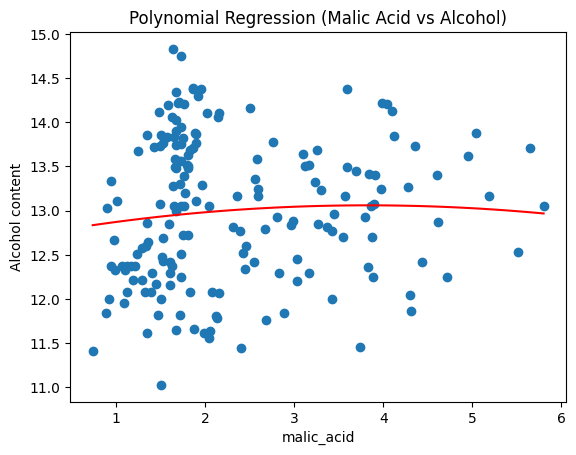

In [ ]:
import numpy as np
# Smooth curve for plotting
X_grid = np.linspace(x_single.min(), x_single.max(), 100).reshape(-1, 1)
X_grid_poly = poly_single.transform(X_grid)
y_grid_pred = model_single_feature.predict(X_grid_poly)

plt.scatter(x_single, y)
plt.plot(X_grid, y_grid_pred, color='red')
plt.xlabel(X.columns[0])
plt.ylabel('Alcohol content')
plt.title("Polynomial Regression (Malic Acid vs Alcohol)")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
model2 = LogisticRegression()

In [ ]:
model2 = LogisticRegression(solver='liblinear')

In [ ]:
# For demonstration, let's create a binary classification problem
# E.g., classify wines as 'high alcohol' (True) or 'low alcohol' (False) based on a threshold
# Let's use the median alcohol content as a threshold
median_alcohol = y.median()
y_classification = (y > median_alcohol).astype(int)

# Split the new classification target
X1_clf, X2_clf, y1_clf, y2_clf = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Fit the Logistic Regression model with the new classification target
p2 = model2.fit(X1_clf, y1_clf)

print(f"Median alcohol content used for classification: {median_alcohol:.2f}")
print(f"Target variable (y_classification) head:\n{y_classification.head()}")
print(f"Value counts for y1_clf:\n{y1_clf.value_counts()}")

Median alcohol content used for classification: 13.05
Target variable (y_classification) head:
0    1
1    1
2    1
3    1
4    1
Name: alcohol, dtype: int64
Value counts for y1_clf:
alcohol
0    78
1    64
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
pred = p2.predict(X2_clf)
pred

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1])

In [ ]:
c = confusion_matrix(y2_clf, pred)
print(c)

[[14  1]
 [ 4 17]]


Support vector machine

In [ ]:
from sklearn import svm

In [ ]:
data = pd.read_csv("/content/wine.data", header=None) # Load without header, as per wine.data format

In [ ]:
x = data.iloc[:,1:]
y = data.iloc[:,0]

In [ ]:
x

,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
y

,1
0,1
1,1
2,1
3,1
4,1
...,...
172,3
173,3
174,3
175,3


In [ ]:
x1,x2,y1,y2 = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
m = svm.SVC(kernel='linear')
m.fit(x1,y1)

SVC(kernel='linear')

In [ ]:
p = m.predict(x2)
acc = accuracy_score(y2,p)


In [ ]:
print("confusion matrix:",confusion_matrix(y2,p))

confusion matrix: [[14  1  0]
 [ 0 16  2]
 [ 0  0 12]]


In [ ]:
m2 = svm.SVC(kernel='rbf', random_state=2)
m2.fit(x1,y1)
print(m2)
p2 = m2.predict(x2)
acc2 = accuracy_score(y2,p)
print(p2)
print(acc2)

SVC(random_state=2)
[3 1 2 1 3 1 2 3 2 3 3 2 1 2 1 2 2 2 1 2 3 2 2 2 2 2 2 2 2 1 1 2 3 1 1 3 1
 2 2 2 3 2 2 3 2]
0.9333333333333333


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
from sklearn import neighbors,metrics

In [ ]:
data.columns

Index(['1', '14.23', '1.71', '2.43', '15.6', '127', '2.8', '3.06', '.28',
       '2.29', '5.64', '1.04', '3.92', '1065'],
      dtype='object')

In [ ]:
data.columns = list('ABCDEFGHIJKLMN')

In [ ]:
x = data.iloc[:, 1:].values

In [ ]:
y = data['A'].values.ravel() # Ensure y is a 1D array
print(x,y)

[[ 1.   13.2   1.78 ...  4.38  1.05  3.4 ]
 [ 1.   13.16  2.36 ...  5.68  1.03  3.17]
 [ 1.   14.37  1.95 ...  7.8   0.86  3.45]
 ...
 [ 3.   13.27  4.28 ... 10.2   0.59  1.56]
 [ 3.   13.17  2.59 ...  9.3   0.6   1.62]
 [ 3.   14.13  4.1  ...  9.2   0.61  1.6 ]]         N
0    1050
1    1185
2    1480
3     735
4    1450
..    ...
172   740
173   750
174   835
175   840
176   560

[177 rows x 1 columns]


In [4]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Removed incorrect LabelEncoder application. StandardScaler will be used instead.

[[  0.  65.  49. ...  56.  50. 102.]
 [  0.  63.  71. ...  82.  48.  86.]
 [  0. 120.  59. ... 108.  30. 104.]
 ...
 [  2.  68. 119. ... 124.   6.  10.]
 [  2.  64.  81. ... 119.   7.  14.]
 [  2. 112. 117. ... 118.   8.  13.]]


In [ ]:
x1,x2,y1,y2 = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x1)
X_test_scaled = scaler.transform(x2)

In [ ]:
model = neighbors.KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled,y1) # Use scaled training data
p1 = model.predict(X_test_scaled) # Use scaled test data for prediction
a1 = metrics.accuracy_score(y2, p1)
print("predict:",p1)
print("confusion matrix:" ,confusion_matrix(y2,p1))
print("accuracy:",a1)

predict: [ 795  985  520  920  355 1310  352  650  380  510  735  520 1190  290
  915  355  434  315 1060  278 1035  278  650  500  510  500  510  428
  480  795 1060  312  510 1035 1045  770  520  520  290  650  795  520
  434  450  580]
confusion matrix: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
accuracy: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

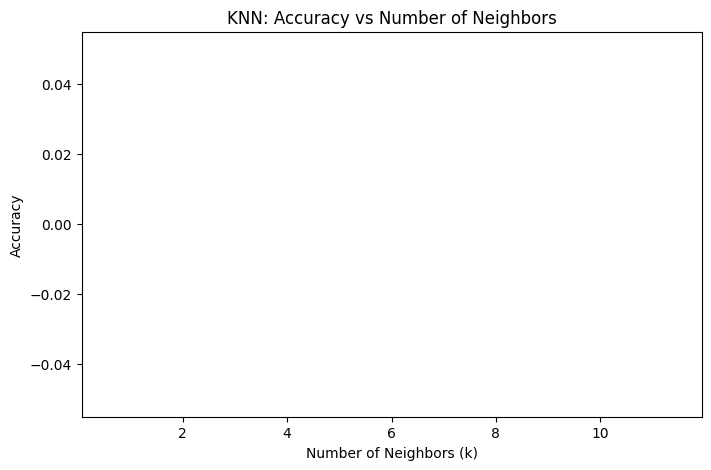

In [ ]:
neighbors_list = [1,3,5,7,9,11]
accuracies = []

for n in neighbors_list:
    model = neighbors.KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train_scaled, y1) # Use scaled training data
    p1 = model.predict(X_test_scaled) # Use scaled test data for prediction
    a1 = metrics.accuracy_score(y2, p1)
    accuracies.append(a1)

plt.figure(figsize=(8, 5))
plt.bar(neighbors_list, accuracies, color='skyblue')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs Number of Neighbors')
plt.show()

KMeans

In [ ]:
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans

In [ ]:
digits = load_digits()
x = digits.data
y = digits.target

In [ ]:
df = pd.DataFrame(x, columns=digits.feature_names)
df['digits class'] = y

In [ ]:
print(df.describe())


       pixel_0_0    pixel_0_1    pixel_0_2    pixel_0_3    pixel_0_4  \
count     1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean         0.0     0.303840     5.204786    11.835838    11.848080   
std          0.0     0.907192     4.754826     4.248842     4.287388   
min          0.0     0.000000     0.000000     0.000000     0.000000   
25%          0.0     0.000000     1.000000    10.000000    10.000000   
50%          0.0     0.000000     4.000000    13.000000    13.000000   
75%          0.0     0.000000     9.000000    15.000000    15.000000   
max          0.0     8.000000    16.000000    16.000000    16.000000   

         pixel_0_5    pixel_0_6    pixel_0_7    pixel_1_0    pixel_1_1  ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000    

In [ ]:
sc = StandardScaler()
x = sc.fit_transform(x)
# print(x)
wss=[]
for i in range(1,10):
    KM = KMeans(n_clusters = i, init = 'k-means++', random_state = 0)
    KM.fit(x)
    wss.append(KM.inertia_)


Text(0, 0.5, 'wss-kmeans')

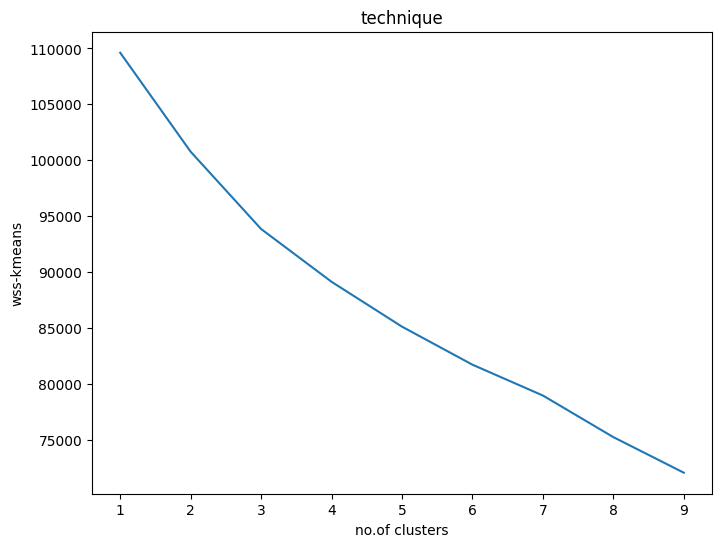

In [ ]:
f, ax = plt.subplots(figsize=(8,6))
plt.plot(range(1,10),wss)
plt.title("technique")
plt.xlabel("no.of clusters")
plt.ylabel("wss-kmeans")
# plt.show()

In [ ]:
N = 4
km = KMeans(init= 'k-means++', n_clusters=N)
km.fit(x)
labels = km.labels_
# print(labels)

ac = accuracy_score(labels,y)
print(ac)

0.001669449081803005


Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.model_selection import validation_curve

In [ ]:
rfc2 = RandomForestClassifier(n_estimators=1000, min_samples_split=3, max_depth=15, random_state=0)
rfc2.fit(x1,y1)
p2 = rfc2.predict(x2)
print(p2)
ac = accuracy_score(p2, y2)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[1035 1045  520 1285  680 1375  434  695  380  510  735  520  985  495
 1060  680  378  480 1060  355  985  630  680  560  520  550  428  392
  495  795 1270  345  520 1035 1547 1035  560  740  290  660 1080  345
  562  710  520]


In [ ]:
feature_score = pd.Series(rfc2.feature_importances_, index = data.columns[1:]).sort_values(ascending=False)
print(feature_score)

D    0.088967
N    0.087440
I    0.085140
H    0.083374
M    0.082553
E    0.082366
K    0.082063
J    0.081264
L    0.081163
F    0.078043
G    0.077537
C    0.076693
B    0.013396
dtype: float64


Text(0.5, 0, 'feature importance score')

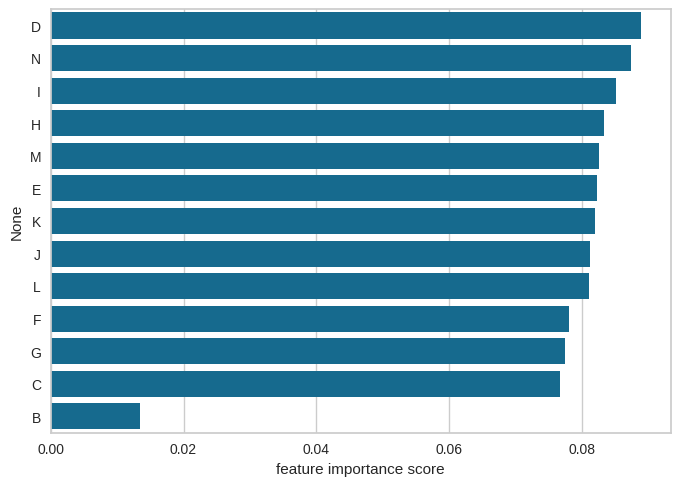

In [ ]:
import seaborn as sns
sns.barplot(x = feature_score, y = feature_score.index)
plt.xlabel("feature importance score")
plt.show()


Decision tree

prediction: [6 9 3 7 2 1 5 3 5 2 2 5 4 0 4 2 3 7 8 4 4 3 9 7 5 6 3 5 6 3 4 9 1 4 4 6 9
 4 7 6 6 3 1 3 6 1 3 0 6 5 5 1 4 5 6 0 3 0 0 8 5 4 3 2 4 5 7 0 7 5 9 5 5 4
 7 0 4 5 5 9 9 0 2 3 8 0 6 4 4 3 1 2 5 3 9 2 9 4 4 7 4 3 4 3 8 3 5 9 4 2 7
 7 4 5 1 9 2 7 3 3 2 6 9 6 0 7 2 7 5 8 7 5 7 2 0 6 6 4 2 8 0 9 4 6 9 9 6 9
 0 3 5 6 6 0 6 4 3 9 3 7 7 2 9 0 4 5 8 6 5 9 9 8 4 2 1 4 7 7 2 2 3 9 8 0 3
 1 2 5 6 9 9 4 4 6 4 2 3 6 4 8 5 9 5 7 1 9 4 8 1 5 4 4 9 6 1 7 6 0 4 5 2 7
 4 6 4 5 6 4 3 2 3 6 7 1 5 1 4 7 6 9 1 5 5 1 6 2 8 8 9 9 7 4 2 0 2 3 5 2 3
 3 6 0 7 7 7 0 1 0 4 5 1 5 3 6 0 4 1 0 2 3 6 2 9 7 7 5 5 9 9 8 5 3 3 2 0 5
 8 3 4 0 2 4 6 9 3 9 5 0 5 2 1 3 1 4 7 1 7 0 1 5 2 1 3 8 7 0 6 4 8 8 5 1 8
 4 5 9 5 9 8 6 0 8 2 0 9 9 8 9 5 2 7 4 9 7 7 4 3 8 9 5]
accuracy_score: 0.8472222222222222


[Text(0.24602409918276374, 0.96875, 'x[36] <= -1.652\ngini = 0.9\nsamples = 1437\nvalue = [145, 154, 144, 149, 135, 135, 146, 145, 144, 140]'),
 Text(0.05794947994056464, 0.90625, 'x[42] <= -0.288\ngini = 0.539\nsamples = 223\nvalue = [143, 0, 3, 1, 6, 17, 4, 0, 3, 46]'),
 Text(0.1519867895616642, 0.9375, 'True  '),
 Text(0.0237741456166419, 0.84375, 'x[21] <= -0.211\ngini = 0.376\nsamples = 59\nvalue = [0, 0, 1, 1, 0, 12, 0, 0, 0, 45]'),
 Text(0.01188707280832095, 0.78125, 'x[19] <= 0.777\ngini = 0.272\nsamples = 13\nvalue = [0, 0, 1, 0, 0, 11, 0, 0, 0, 1]'),
 Text(0.005943536404160475, 0.71875, 'gini = 0.0\nsamples = 11\nvalue = [0, 0, 0, 0, 0, 11, 0, 0, 0, 0]'),
 Text(0.017830609212481426, 0.71875, 'x[52] <= -0.645\ngini = 0.5\nsamples = 2\nvalue = [0, 0, 1, 0, 0, 0, 0, 0, 0, 1]'),
 Text(0.01188707280832095, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]'),
 Text(0.0237741456166419, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]'

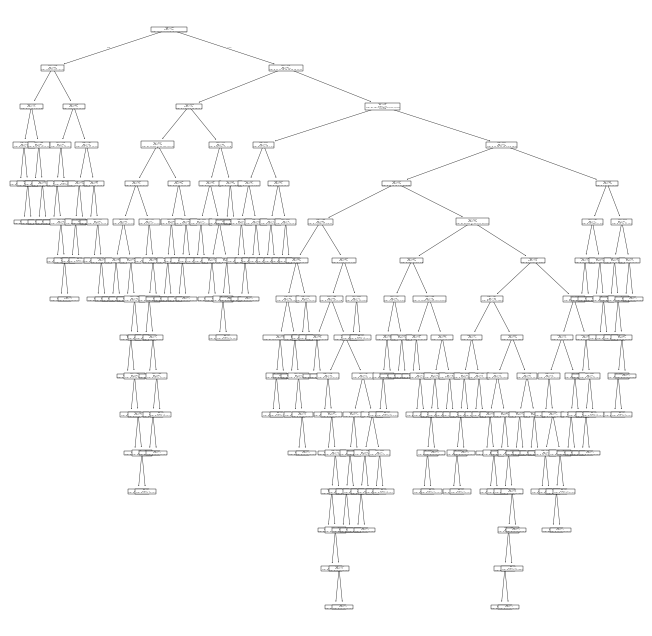

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree
x1,x2,y1,y2 = train_test_split(x,y, test_size=0.2,random_state=42)

cg = DecisionTreeClassifier(criterion='gini', random_state=0)
cg.fit(x1,y1)
pred = cg.predict(x2)
print("prediction:", pred)
ac = accuracy_score(y2,pred)
print("accuracy_score:" ,ac)

plt.figure(figsize=(8,8))
tree.plot_tree(cg.fit(x1,y1))
# plt.show()

[6 9 3 7 6 2 7 3 7 7 2 9 8 0 6 8 3 7 2 8 8 3 9 8 7 6 3 7 6 8 6 3 3 6 7 6 9
 8 7 6 6 3 6 8 6 2 3 0 6 9 9 2 9 9 6 0 3 0 0 2 9 8 9 2 6 9 8 0 8 9 9 9 9 8
 7 0 6 7 9 3 9 0 2 3 8 0 6 8 6 3 2 2 8 3 9 2 9 8 7 8 8 3 9 3 9 2 7 9 8 2 3
 8 8 6 2 3 8 7 8 8 2 6 9 9 0 6 5 8 7 8 8 9 7 9 0 6 6 7 2 8 0 9 8 6 9 9 6 3
 0 9 9 6 6 0 6 8 3 3 3 7 8 6 3 0 6 9 2 6 7 7 9 8 8 8 8 3 7 7 2 2 3 9 8 0 3
 8 2 9 6 9 9 8 6 5 9 8 3 6 7 8 9 9 9 7 8 9 8 8 2 9 8 8 9 6 8 8 6 0 9 7 8 7
 8 6 8 6 6 8 3 2 3 6 8 9 9 3 8 8 6 9 8 9 7 8 8 2 8 8 9 7 7 0 2 7 2 3 6 2 7
 3 6 0 9 8 7 0 2 0 8 9 8 7 3 6 0 8 2 0 0 8 6 9 9 7 3 9 9 9 9 8 9 3 3 8 0 7
 8 3 8 0 2 7 6 8 3 8 9 0 9 2 3 3 9 8 7 8 8 0 8 7 6 8 2 8 7 0 6 8 8 2 9 2 8
 7 9 8 9 9 8 6 0 2 8 0 9 9 8 3 9 2 7 8 9 2 7 6 3 8 8 9]
accuracy_score: 0.4861111111111111


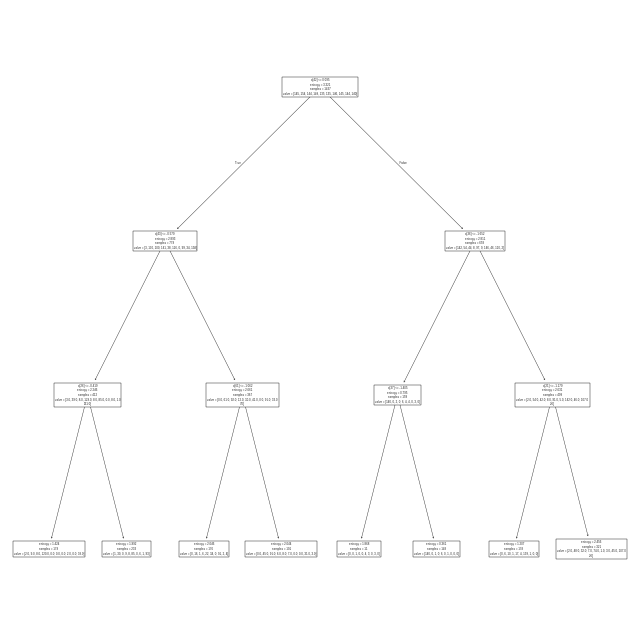

In [ ]:
centro = DecisionTreeClassifier(criterion='entropy',max_depth=3, random_state=0)
centro.fit(x1,y1)
p2 = centro.predict(x2)
print(p2)
a2 = accuracy_score(y2, p2)
print("accuracy_score:" , a2)

plt.figure(figsize=(8,8))
tree.plot_tree(centro.fit(x1,y1))
plt.show()

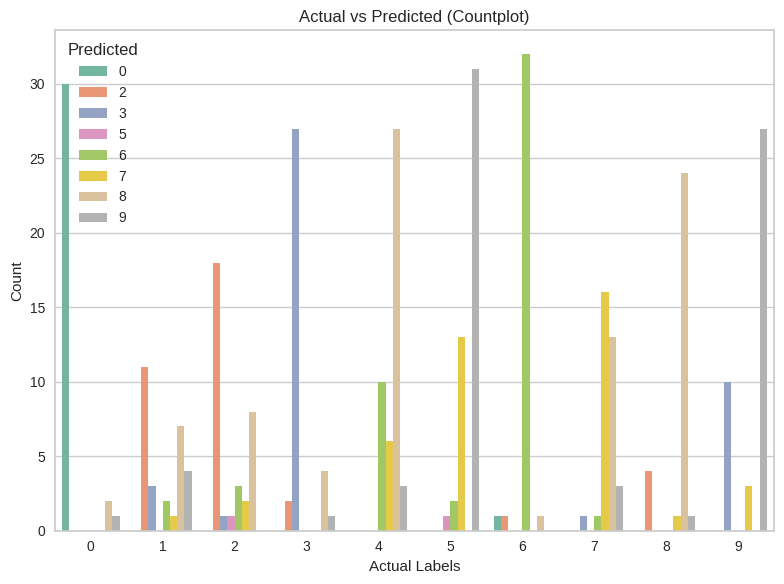

In [ ]:
res = pd.DataFrame({'Actual': y2, 'Predicted': p2})
plt.figure(figsize=(8,6))
sns.countplot(data=res, x='Actual', hue='Predicted', palette='Set2')
plt.title('Actual vs Predicted (Countplot)')
plt.xlabel('Actual Labels')
plt.ylabel('Count')
plt.legend(title='Predicted')
plt.tight_layout()
plt.show()

PCA

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Reduced Data:\n", X_pca)


Explained Variance Ratio: [0.36198848]
Reduced Data:
 [[ 3.31675081]
 [ 2.20946492]
 [ 2.51674015]
 [ 3.75706561]
 [ 1.00890849]
 [ 3.05025392]
 [ 2.44908967]
 [ 2.05943687]
 [ 2.5108743 ]
 [ 2.75362819]
 [ 3.47973668]
 [ 1.7547529 ]
 [ 2.11346234]
 [ 3.45815682]
 [ 4.31278391]
 [ 2.3051882 ]
 [ 2.17195527]
 [ 1.89897118]
 [ 3.54198508]
 [ 2.0845222 ]
 [ 3.12440254]
 [ 1.08657007]
 [ 2.53522408]
 [ 1.64498834]
 [ 1.76157587]
 [ 0.9900791 ]
 [ 1.77527763]
 [ 1.23542396]
 [ 2.18840633]
 [ 2.25610898]
 [ 2.50022003]
 [ 2.67741105]
 [ 1.62857912]
 [ 1.90269086]
 [ 1.41038853]
 [ 1.90382623]
 [ 1.38486223]
 [ 1.12220741]
 [ 1.5021945 ]
 [ 2.52980109]
 [ 2.58809543]
 [ 0.66848199]
 [ 3.07080699]
 [ 0.46220914]
 [ 2.10135193]
 [ 1.13616618]
 [ 2.72660096]
 [ 2.82133927]
 [ 2.00985085]
 [ 2.7074913 ]
 [ 3.21491747]
 [ 2.85895983]
 [ 3.50560436]
 [ 2.22479138]
 [ 2.14698782]
 [ 2.46932948]
 [ 2.74151791]
 [ 2.17374092]
 [ 3.13938015]
 [-0.92858197]
 [-1.54248014]
 [-1.83624976]
 [ 0.03060683]
 

Association analysis -- apriori, Frequent pattern Growth (FP Growth)

In [ ]:
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter', 'Jam']
]


In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)
print(df)


   Bread  Butter    Jam   Milk
0   True    True  False   True
1   True    True  False  False
2   True   False  False   True
3  False    True  False   True
4   True    True   True  False
5   True    True   True   True


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori
frequent_itemsets = apriori(
    df,
    min_support=0.3,
    use_colnames=True
)

print("Frequent Itemsets:")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Frequent Itemsets:
     support               itemsets
0   0.833333                (Bread)
1   0.833333               (Butter)
2   0.333333                  (Jam)
3   0.666667                 (Milk)
4   0.666667        (Bread, Butter)
5   0.333333           (Bread, Jam)
6   0.500000          (Bread, Milk)
7   0.333333          (Jam, Butter)
8   0.500000         (Milk, Butter)
9   0.333333   (Bread, Jam, Butter)
10  0.333333  (Bread, Milk, Butter)

Association Rules:
       antecedents      consequents   support  confidence  lift
0          (Bread)         (Butter)  0.666667    0.800000  0.96
1         (Butter)          (Bread)  0.666667    0.800000  0.96
2            (Jam)          (Bread)  0.333333    1.000000  1.20
3          (Bread)           (Milk)  0.500000    0.600000  0.90
4           (Milk)          (Bread)  0.500000    0.750000  0.90
5            (Jam)         (Butter)  0.333333    1.000000  1.20
6           (Milk)         (Butter)  0.500000    0.750000  0.90
7         (Butter

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# Apply FP-Growth
frequent_itemsets_fp = fpgrowth(
    df,
    min_support=0.3,
    use_colnames=True
)

print("Frequent Itemsets (FP-Growth):")
print(frequent_itemsets_fp)

# Generate association rules
rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.6
)

print("\nAssociation Rules (FP-Growth):")
print(rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Frequent Itemsets (FP-Growth):
     support               itemsets
0   0.833333                (Bread)
1   0.833333               (Butter)
2   0.666667                 (Milk)
3   0.333333                  (Jam)
4   0.666667        (Bread, Butter)
5   0.500000         (Milk, Butter)
6   0.500000          (Bread, Milk)
7   0.333333  (Bread, Milk, Butter)
8   0.333333          (Jam, Butter)
9   0.333333           (Bread, Jam)
10  0.333333   (Bread, Jam, Butter)

Association Rules (FP-Growth):
       antecedents      consequents   support  confidence  lift
0          (Bread)         (Butter)  0.666667    0.800000  0.96
1         (Butter)          (Bread)  0.666667    0.800000  0.96
2           (Milk)         (Butter)  0.500000    0.750000  0.90
3         (Butter)           (Milk)  0.500000    0.600000  0.90
4          (Bread)           (Milk)  0.500000    0.600000  0.90
5           (Milk)          (Bread)  0.500000    0.750000  0.90
6    (Bread, Milk)         (Butter)  0.333333    0.666667

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Hidden Markov Model

In [ ]:
# Observations (shape: n_samples, n_features)
observations = np.array([[1], [2], [3], [2], [1], [2], [3], [3], [2], [1]])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
pip install hmmlearn


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/166.0 kB ? eta -:--:--

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import numpy as np
from hmmlearn import hmm


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
model = hmm.GaussianHMM(
    n_components=2,        # number of hidden states
    covariance_type="diag",
    n_iter=100,
    random_state=42
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
model.fit(observations)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

GaussianHMM(n_components=2, n_iter=100, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
hidden_states = model.predict(observations)

print("Hidden states sequence:")
print(hidden_states)


Hidden states sequence:
[1 0 0 0 1 0 0 0 0 1]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Initial probabilities:")
print(model.startprob_)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Initial probabilities:
[1.26478742e-15 1.00000000e+00]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Transition matrix:")
print(model.transmat_)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Transition matrix:
[[7.15609993e-001 2.84390007e-001]
 [1.00000000e+000 1.74983753e-265]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Means:")
print(model.means_)

print("Variances:")
print(model.covars_)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Means:
[[2.42688236]
 [1.        ]]
Variances:
[[[0.24844538]]

 [[0.00334257]]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Create random data points
X = np.array([
    [1, 2], [1, 4], [1, 0],
    [10, 2], [10, 4], [10, 0],
    [5, 8], [6, 9], [4, 7]
])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

KMeans(n_clusters=3, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

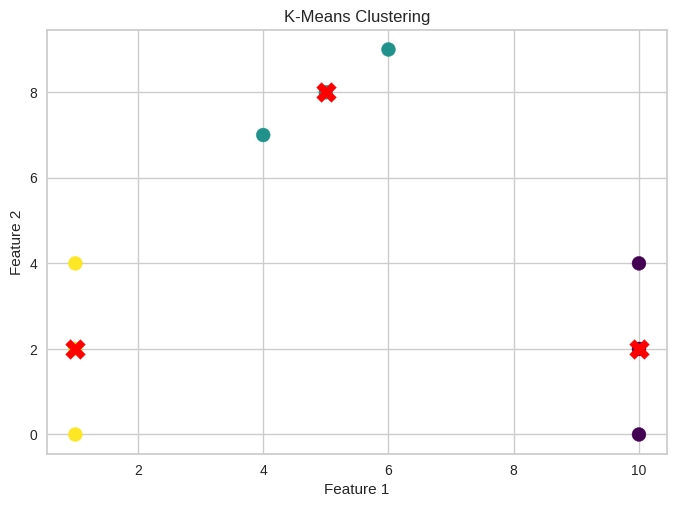

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
wine = load_wine()
X = wine.data
y = wine.target   # actual labels (not used in clustering)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

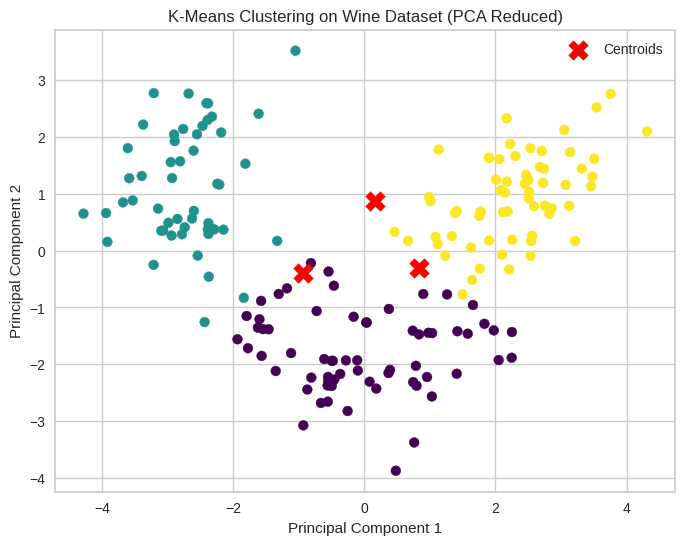

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering on Wine Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


In [6]:
wine = load_wine()
X = wine.data
y = wine.target   # actual labels (not used in clustering)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


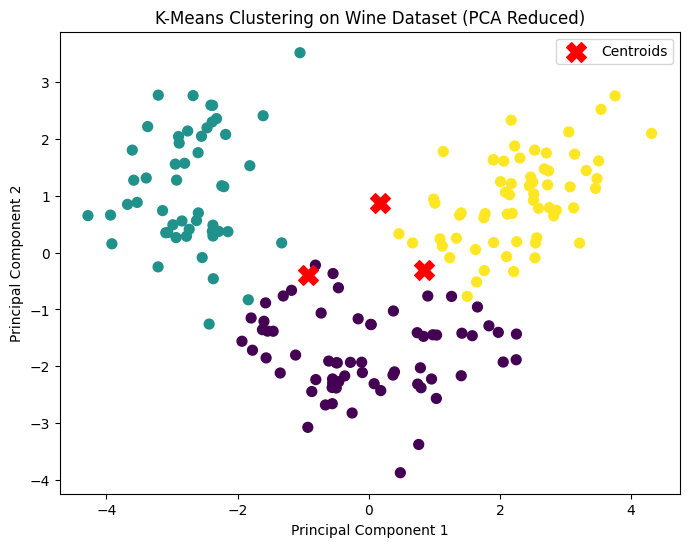

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering on Wine Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()
